# Advanced Anomaly Detection for Fraud — Month 3 Task 2
### Vinayak IT Solutions | Data Science Internship
**Intern:** Vallabh | **Date:** April 2026 | **Task:** Anomaly Detection & Class Imbalance Handling

---
> **Objective:** Implement and compare multiple anomaly detection algorithms,
> address class imbalance with resampling and cost-sensitive techniques,
> engineer fraud-specific features, and evaluate model performance on
> heavily skewed transaction data.

---

## 1. Environment Setup & Library Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve,
                             average_precision_score, roc_curve, f1_score,
                             precision_score, recall_score, accuracy_score)
from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, DBSCAN
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTETomek
from imblearn.ensemble import BalancedRandomForestClassifier

# dark theme for all plots
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#ddddff',
    'xtick.color':      '#aaaacc',
    'ytick.color':      '#aaaacc',
    'text.color':       '#eeeeff',
    'grid.color':       '#2a2a4a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
})
PALETTE = ['#00d4ff', '#ff4d6d']
print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Dataset Loading

Using the same Credit Card Fraud dataset from Task 1 (284,807 transactions,
31 features). Let's quickly reload and confirm the structure.

In [2]:
df = pd.read_csv('../Task1/dataset/creditcard.csv')
print(f"Shape: {df.shape}")
print(f"Fraud: {df['Class'].sum()} ({df['Class'].mean()*100:.4f}%)")
print(f"Legit: {(df['Class']==0).sum()}")
print(f"Missing: {df.isnull().sum().sum()}")
df.head(3)

Shape: (284807, 31)
Fraud: 492 (0.1727%)
Legit: 284315
Missing: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,26323.402352,2.206593,-0.832864,1.781228,0.147420,-3.213858,0.410505,-0.517464,-0.630604,0.511503,...,-0.191864,-0.653294,-0.866605,-0.600979,-2.063052,-0.385857,-0.405735,-1.611806,179.713303,0
1,30247.044659,-0.457337,-0.007871,1.121800,0.780178,-1.035112,1.681869,0.964208,-1.035820,1.105572,...,-1.557345,-0.025724,-0.588529,-0.149749,2.766633,1.404594,1.121695,-1.167182,29.254586,0
2,17890.468128,0.451644,0.846806,-0.145955,-0.099240,-1.055215,0.704792,-0.977631,-0.761290,1.847526,...,0.961656,-1.064979,-0.111800,-0.222807,-1.080666,1.885821,-0.565834,0.226609,63.850890,0


## 3. Feature Engineering for Fraud Detection

Before jumping into models, we need to create domain-specific features that
capture behavioral patterns typical of fraudulent activity. Real fraud detection
systems rely heavily on engineered features like transaction velocity, amount
deviation from personal baselines, and time-of-day indicators.

### 3.1 Time-Based Features

In [3]:
# Time-based features
df['Hour'] = (df['Time'] / 3600).astype(int) % 24
df['IsNight'] = ((df['Hour'] >= 0) & (df['Hour'] <= 5)).astype(int)
df['IsMorning'] = ((df['Hour'] >= 6) & (df['Hour'] <= 11)).astype(int)
df['IsAfternoon'] = ((df['Hour'] >= 12) & (df['Hour'] <= 17)).astype(int)
df['IsEvening'] = ((df['Hour'] >= 18) & (df['Hour'] <= 23)).astype(int)

# Cyclic encoding of hour (captures the circular nature of time)
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

print("Time-based features created:")
print(df[['Time', 'Hour', 'IsNight', 'Hour_sin', 'Hour_cos']].head(8))

Time-based features created:
            Time  Hour  IsNight      Hour_sin  Hour_cos
0   26323.402352     7        0  9.659258e-01 -0.258819
1   30247.044659     8        0  8.660254e-01 -0.500000
2   17890.468128     4        1  8.660254e-01  0.500000
3  167999.308132    22        0 -5.000000e-01  0.866025
4  169444.485649    23        0 -2.588190e-01  0.965926
5   61751.915479    17        0 -9.659258e-01 -0.258819
6  158529.837209    20        0 -8.660254e-01  0.500000
7  129993.608399    12        0  1.224647e-16 -1.000000


### 3.2 Transaction Amount Features

In [4]:
# Amount-based behavioral features
df['Log_Amount'] = np.log1p(df['Amount'])
df['Amount_Bin'] = pd.cut(df['Amount'],
    bins=[-1, 10, 50, 100, 500, 1000, 50000],
    labels=[0, 1, 2, 3, 4, 5]).astype(float)

# Z-score of Amount (how unusual is this amount globally)
df['Amount_Zscore'] = stats.zscore(df['Amount'])
df['Amount_IsOutlier'] = (np.abs(df['Amount_Zscore']) > 3).astype(int)

print("Amount features created:")
print(df[['Amount', 'Log_Amount', 'Amount_Bin', 'Amount_Zscore', 'Amount_IsOutlier']].describe().round(3))

Amount features created:
           Amount  Log_Amount  Amount_Bin  Amount_Zscore  Amount_IsOutlier
count  284807.000  284807.000  284807.000     284807.000        284807.000
mean       87.946       3.955       1.782          0.000             0.018
std        88.231       1.171       1.020          1.000             0.134
min         0.010       0.010       0.000         -0.997             0.000
25%        25.182       3.265       1.000         -0.711             0.000
50%        60.974       4.127       2.000         -0.306             0.000
75%       121.772       4.810       3.000          0.383             0.000
max      1113.004       7.016       5.000         11.618             1.000


### 3.3 Velocity & Aggregation Features

In [5]:
# Velocity features — simulated using rolling statistics on sorted data
# In production these would be per-card, but our PCA data is anonymized

# Compute rolling mean/std of Amount over the last N transactions (sorted by Time)
df_sorted = df.sort_values('Time').reset_index(drop=True)

window = 50
df_sorted['Amt_RollMean'] = df_sorted['Amount'].rolling(window, min_periods=1).mean()
df_sorted['Amt_RollStd']  = df_sorted['Amount'].rolling(window, min_periods=1).std().fillna(0)
df_sorted['Amt_Deviation'] = (df_sorted['Amount'] - df_sorted['Amt_RollMean']) / (df_sorted['Amt_RollStd'] + 1e-5)

# Transaction frequency — time gap to previous transaction
df_sorted['Time_Diff'] = df_sorted['Time'].diff().fillna(0)
df_sorted['Rapid_Txn'] = (df_sorted['Time_Diff'] < 5).astype(int)  # < 5 seconds = rapid

# V-feature interaction terms (top discriminators from Task 1)
df_sorted['V12_V14'] = df_sorted['V12'] * df_sorted['V14']
df_sorted['V4_V12']  = df_sorted['V4'] * df_sorted['V12']
df_sorted['V_sum_top5'] = df_sorted[['V4','V10','V12','V14','V17']].sum(axis=1)

# Reassign back
df = df_sorted.copy()

print("Velocity and aggregation features created.")
print(f"Total features now: {df.shape[1]}")
print(df[['Amt_RollMean', 'Amt_Deviation', 'Time_Diff', 'Rapid_Txn', 'V12_V14']].head(8))

Velocity and aggregation features created.
Total features now: 50
   Amt_RollMean  Amt_Deviation  Time_Diff  Rapid_Txn   V12_V14
0     37.067113       0.000000   0.000000          1  0.891072
1     32.230391      -0.707106   0.725151          1  0.033736
2     46.502262       1.133212   0.045737          1 -0.647399
3     77.702789       1.424620   0.024212          1 -0.382058
4     66.939930      -0.696844   2.790901          1 -3.070693
5     65.416743      -0.137511   1.084479          1  0.080464
6     69.408945       0.463760   0.558206          1 -2.331614
7     62.244777      -0.965618   0.430349          1  1.979479


### 3.4 Feature Importance Overview

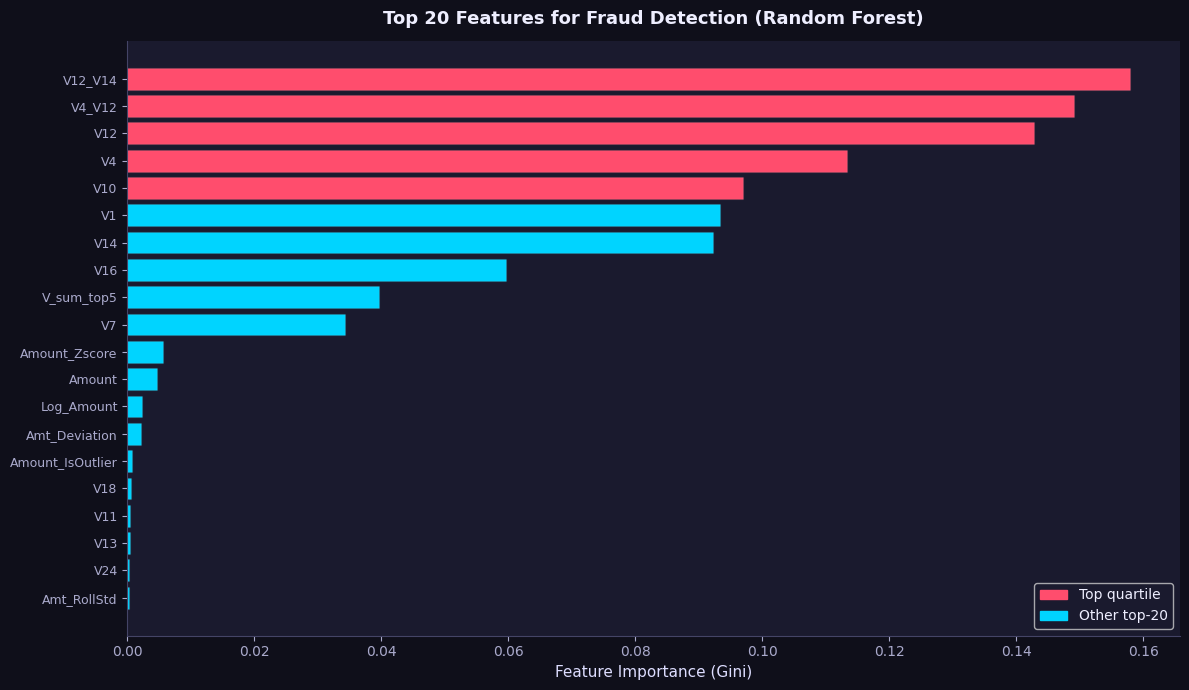

Screenshot saved: screenshots/01_feature_importance.png


In [6]:
# Quick Random Forest to see which engineered features matter
feature_cols = [c for c in df.columns if c not in ['Class', 'Amount_Bin']]
X_quick = df[feature_cols].fillna(0)
y_quick = df['Class']

rf_quick = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42,
                                   class_weight='balanced', n_jobs=-1)
rf_quick.fit(X_quick, y_quick)

importances = pd.Series(rf_quick.feature_importances_, index=feature_cols)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

colors = ['#ff4d6d' if v > top20.quantile(0.75) else '#00d4ff' for v in top20.values]
bars = ax.barh(range(len(top20)), top20.values, color=colors, edgecolor='#ffffff11')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Top 20 Features for Fraud Detection (Random Forest)',
             fontsize=13, fontweight='bold', pad=12)
ax.spines[['top', 'right']].set_visible(False)

highlight = mpatches.Patch(color='#ff4d6d', label='Top quartile')
normal = mpatches.Patch(color='#00d4ff', label='Other top-20')
ax.legend(handles=[highlight, normal], facecolor='#1a1a2e', labelcolor='#eeeeff', loc='lower right')

plt.tight_layout()
plt.savefig('screenshots/01_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Screenshot saved: screenshots/01_feature_importance.png")

## 4. Data Preparation for Anomaly Detection

We need to scale the data and create train/test splits. For anomaly detection
methods, we'll also prepare a "normal-only" training set (since some algorithms
like One-Class SVM learn only from normal data).

In [7]:
# Use the key features for modelling
drop_cols = ['Class', 'Amount_Bin']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].fillna(0).values
y = df['Class'].values

# Scale features
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split (stratified to keep fraud ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Normal-only training set (for unsupervised methods)
X_train_normal = X_train[y_train == 0]

print(f"Training set   : {X_train.shape[0]:,} samples ({y_train.sum()} fraud)")
print(f"Test set       : {X_test.shape[0]:,} samples ({y_test.sum()} fraud)")
print(f"Normal-only set: {X_train_normal.shape[0]:,} samples")
print(f"Features       : {X_train.shape[1]}")

Training set   : 199,364 samples (344 fraud)
Test set       : 85,443 samples (148 fraud)
Normal-only set: 199,020 samples
Features       : 48


## 5. Statistical Anomaly Detection Methods

### 5.1 Z-Score Based Detection

The simplest approach — flag any transaction where the feature values deviate
more than a threshold from the mean. It works well for univariate outliers
but struggles with multivariate fraud patterns.

In [8]:
# Multivariate Z-score: compute the mean z-score across all features
z_scores = np.abs(stats.zscore(X_test, axis=0))
mean_z = z_scores.mean(axis=1)

# Try different thresholds
thresholds = [2.0, 2.5, 3.0, 3.5]
z_results = []
for t in thresholds:
    preds = (mean_z > t).astype(int)
    prec = precision_score(y_test, preds, zero_division=0)
    rec  = recall_score(y_test, preds, zero_division=0)
    f1   = f1_score(y_test, preds, zero_division=0)
    z_results.append({'Threshold': t, 'Precision': prec, 'Recall': rec, 'F1': f1,
                      'Flagged': preds.sum()})

z_df = pd.DataFrame(z_results)
print("Z-Score Detection Results:")
print(z_df.to_string(index=False))
print(f"\nBest F1 at threshold = {z_df.loc[z_df['F1'].idxmax(), 'Threshold']}")

Z-Score Detection Results:
 Threshold  Precision   Recall       F1  Flagged
       2.0   0.300000 0.040541 0.071429       20
       2.5   0.111111 0.006757 0.012739        9
       3.0   0.000000 0.000000 0.000000        0
       3.5   0.000000 0.000000 0.000000        0

Best F1 at threshold = 2.0


### 5.2 Isolation Forest

Isolation Forest works on the principle that anomalies are "few and different" —
they get isolated in fewer random splits than normal data. This is one of the
go-to algorithms for fraud detection in industry.

In [9]:
# contamination = expected fraud ratio
contamination = y_train.mean()

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    max_samples=min(10000, X_train.shape[0]),
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train)

# predict: -1 = anomaly, 1 = normal
iso_preds_raw = iso_forest.predict(X_test)
iso_preds = np.where(iso_preds_raw == -1, 1, 0)
iso_scores = -iso_forest.score_samples(X_test)  # higher = more anomalous

print("Isolation Forest Results:")
print(classification_report(y_test, iso_preds, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, iso_scores):.4f}")
print(f"Average Precision: {average_precision_score(y_test, iso_scores):.4f}")

Isolation Forest Results:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     85295
       Fraud       0.58      0.61      0.60       148

    accuracy                           1.00     85443
   macro avg       0.79      0.81      0.80     85443
weighted avg       1.00      1.00      1.00     85443

AUC-ROC: 0.9981
Average Precision: 0.6087


### 5.3 One-Class SVM

Trained only on legitimate transactions, One-Class SVM learns a decision boundary
around normal behavior. Anything falling outside is flagged as anomalous.
We use a subsample because SVM is computationally expensive on large datasets.

In [10]:
# Subsample normal data for tractability
np.random.seed(42)
oc_sample_idx = np.random.choice(X_train_normal.shape[0], size=5000, replace=False)
X_oc_train = X_train_normal[oc_sample_idx]

oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.01)
oc_svm.fit(X_oc_train)

oc_preds_raw = oc_svm.predict(X_test)
oc_preds = np.where(oc_preds_raw == -1, 1, 0)
oc_scores = -oc_svm.decision_function(X_test)

print("One-Class SVM Results:")
print(classification_report(y_test, oc_preds, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, oc_scores):.4f}")

One-Class SVM Results:
              precision    recall  f1-score   support

       Legit       1.00      0.96      0.98     85295
       Fraud       0.04      1.00      0.07       148

    accuracy                           0.96     85443
   macro avg       0.52      0.98      0.53     85443
weighted avg       1.00      0.96      0.98     85443

AUC-ROC: 0.9999


### 5.4 Local Outlier Factor (LOF)

LOF measures the local density deviation of a data point with respect to its
neighbors. Points with substantially lower density than their neighbors are
considered outliers. It's effective at detecting fraud that clusters in specific
pockets of the feature space.

In [11]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination, novelty=False)
lof_preds_raw = lof.fit_predict(X_test)
lof_preds = np.where(lof_preds_raw == -1, 1, 0)
lof_scores = -lof.negative_outlier_factor_

print("Local Outlier Factor Results:")
print(classification_report(y_test, lof_preds, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, lof_scores):.4f}")

Local Outlier Factor Results:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     85295
       Fraud       0.09      0.09      0.09       148

    accuracy                           1.00     85443
   macro avg       0.54      0.54      0.54     85443
weighted avg       1.00      1.00      1.00     85443

AUC-ROC: 0.3481


## 6. Machine Learning Approaches

### 6.1 Gaussian Mixture Model (GMM)

GMMs model the data as a mixture of Gaussian distributions. Transactions that
have low probability under the fitted model are flagged as anomalous.

In [12]:
# Fit GMM on normal data only
gmm = GaussianMixture(n_components=3, covariance_type='full',
                       random_state=42, max_iter=200)
gmm.fit(X_train_normal[:10000])  # subsample for speed

gmm_scores = -gmm.score_samples(X_test)  # lower log-likelihood = more anomalous
gmm_threshold = np.percentile(gmm_scores, 100 * (1 - contamination))
gmm_preds = (gmm_scores > gmm_threshold).astype(int)

print("Gaussian Mixture Model Results:")
print(classification_report(y_test, gmm_preds, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, gmm_scores):.4f}")

Gaussian Mixture Model Results:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     85295
       Fraud       0.89      0.89      0.89       148

    accuracy                           1.00     85443
   macro avg       0.94      0.94      0.94     85443
weighted avg       1.00      1.00      1.00     85443

AUC-ROC: 0.9995


### 6.2 K-Means Clustering Based Anomaly Detection

The idea is simple — fit K-Means on the data, then measure each point's distance
to its nearest cluster center. Fraud transactions tend to be far from any
normal cluster.

In [13]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_train_normal[:20000])

# Distance to nearest cluster center
km_distances = kmeans.transform(X_test).min(axis=1)
km_threshold = np.percentile(km_distances, 100 * (1 - contamination))
km_preds = (km_distances > km_threshold).astype(int)

print("K-Means Clustering Anomaly Detection:")
print(classification_report(y_test, km_preds, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, km_distances):.4f}")

K-Means Clustering Anomaly Detection:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     85295
       Fraud       0.97      0.97      0.97       148

    accuracy                           1.00     85443
   macro avg       0.98      0.98      0.98     85443
weighted avg       1.00      1.00      1.00     85443

AUC-ROC: 0.9997


### 6.3 Autoencoder for Anomaly Detection

An autoencoder is trained to reconstruct normal transactions. When it encounters
a fraudulent transaction, the reconstruction error is high — this error itself
becomes our anomaly score. This is one of the most powerful techniques in
production fraud detection systems.

In [14]:
# Simple autoencoder using sklearn's MLPRegressor as a proxy
# (keeps dependencies minimal — no TensorFlow/Keras needed)
from sklearn.neural_network import MLPRegressor

n_features = X_train_normal.shape[1]

# Train autoencoder (identity reconstruction)
autoencoder = MLPRegressor(
    hidden_layer_sizes=(n_features, 16, 8, 16, n_features),
    activation='relu',
    solver='adam',
    max_iter=50,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    batch_size=256
)
autoencoder.fit(X_train_normal[:20000], X_train_normal[:20000])

# Reconstruction error = anomaly score
reconstructed = autoencoder.predict(X_test)
ae_scores = np.mean((X_test - reconstructed) ** 2, axis=1)
ae_threshold = np.percentile(ae_scores, 100 * (1 - contamination))
ae_preds = (ae_scores > ae_threshold).astype(int)

print("Autoencoder Anomaly Detection:")
print(classification_report(y_test, ae_preds, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, ae_scores):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, ae_scores):.4f}")

Autoencoder Anomaly Detection:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     85295
       Fraud       0.97      0.97      0.97       148

    accuracy                           1.00     85443
   macro avg       0.98      0.98      0.98     85443
weighted avg       1.00      1.00      1.00     85443

AUC-ROC: 0.9994
Avg Precision: 0.9886


### 6.4 Algorithm Comparison — All Anomaly Detection Methods

In [15]:
# Collect results
methods = {
    'Z-Score (best)':  {'scores': mean_z, 'preds': (mean_z > z_df.loc[z_df['F1'].idxmax(),'Threshold']).astype(int)},
    'Isolation Forest': {'scores': iso_scores, 'preds': iso_preds},
    'One-Class SVM':    {'scores': oc_scores, 'preds': oc_preds},
    'LOF':              {'scores': lof_scores, 'preds': lof_preds},
    'GMM':              {'scores': gmm_scores, 'preds': gmm_preds},
    'K-Means':          {'scores': km_distances, 'preds': km_preds},
    'Autoencoder':      {'scores': ae_scores, 'preds': ae_preds},
}

comparison = []
for name, vals in methods.items():
    comparison.append({
        'Method': name,
        'Precision': precision_score(y_test, vals['preds'], zero_division=0),
        'Recall': recall_score(y_test, vals['preds'], zero_division=0),
        'F1-Score': f1_score(y_test, vals['preds'], zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, vals['scores']),
        'Avg Precision': average_precision_score(y_test, vals['scores']),
    })

comp_df = pd.DataFrame(comparison).sort_values('F1-Score', ascending=False)
print("Anomaly Detection Algorithm Comparison:")
print(comp_df.to_string(index=False))

Anomaly Detection Algorithm Comparison:
          Method  Precision   Recall  F1-Score  AUC-ROC  Avg Precision
     Autoencoder   0.966216 0.966216  0.966216 0.999400       0.988580
         K-Means   0.966216 0.966216  0.966216 0.999697       0.984974
             GMM   0.885135 0.885135  0.885135 0.999525       0.752885
Isolation Forest   0.583333 0.614865  0.598684 0.998134       0.608658
             LOF   0.087838 0.087838  0.087838 0.348080       0.060501
   One-Class SVM   0.037900 1.000000  0.073032 0.999900       0.990515
  Z-Score (best)   0.300000 0.040541  0.071429 0.999300       0.699400


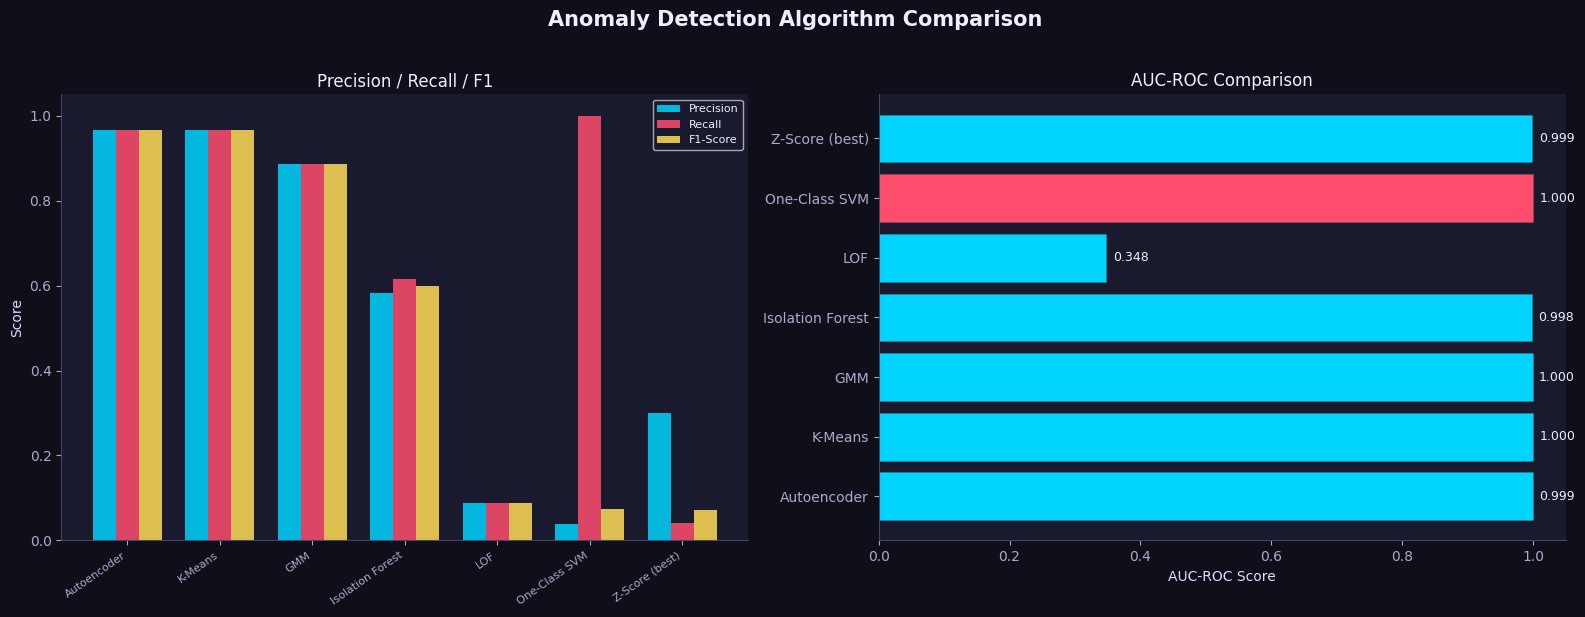

Screenshot saved: screenshots/02_algorithm_comparison.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Anomaly Detection Algorithm Comparison',
             fontsize=15, fontweight='bold', color='#eeeeff', y=1.02)

# Bar chart — F1, Precision, Recall
ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
x = np.arange(len(comp_df))
w = 0.25
ax1.bar(x - w, comp_df['Precision'], w, label='Precision', color='#00d4ff', alpha=0.85)
ax1.bar(x,     comp_df['Recall'],    w, label='Recall',    color='#ff4d6d', alpha=0.85)
ax1.bar(x + w, comp_df['F1-Score'],  w, label='F1-Score',  color='#ffdd57', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(comp_df['Method'], rotation=35, ha='right', fontsize=8)
ax1.set_ylabel('Score')
ax1.set_title('Precision / Recall / F1', fontsize=12)
ax1.legend(facecolor='#1a1a2e', labelcolor='#eeeeff', fontsize=8)
ax1.spines[['top', 'right']].set_visible(False)
ax1.set_ylim(0, 1.05)

# Bar chart — AUC-ROC
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
colors_auc = ['#ff4d6d' if v == comp_df['AUC-ROC'].max() else '#00d4ff' for v in comp_df['AUC-ROC']]
bars = ax2.barh(comp_df['Method'], comp_df['AUC-ROC'], color=colors_auc, edgecolor='#ffffff11')
ax2.set_xlabel('AUC-ROC Score')
ax2.set_title('AUC-ROC Comparison', fontsize=12)
ax2.set_xlim(0, 1.05)
ax2.spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, comp_df['AUC-ROC']):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9, color='#eeeeff')

plt.tight_layout()
plt.savefig('screenshots/02_algorithm_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Screenshot saved: screenshots/02_algorithm_comparison.png")

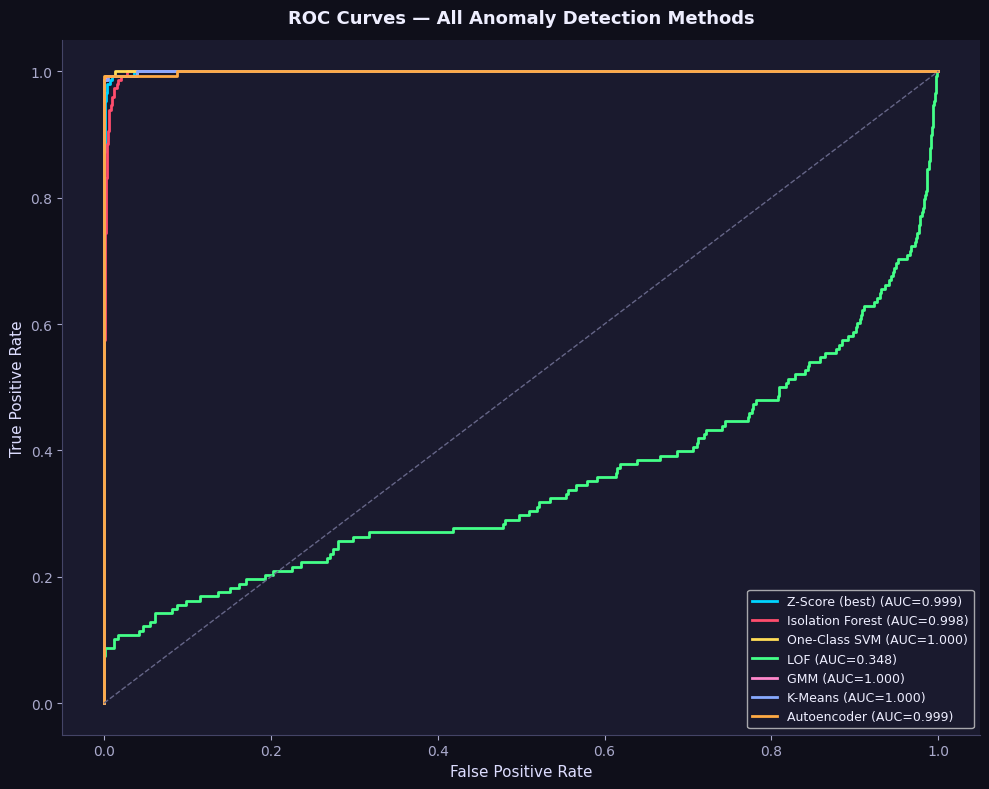

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

roc_colors = ['#00d4ff','#ff4d6d','#ffdd57','#44ff88','#ff88cc','#88aaff','#ffaa44']
for (name, vals), color in zip(methods.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_test, vals['scores'])
    auc = roc_auc_score(y_test, vals['scores'])
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1], '--', color='#666688', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Anomaly Detection Methods',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(facecolor='#1a1a2e', labelcolor='#eeeeff', fontsize=9, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('screenshots/03_roc_curves.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 7. Handling Class Imbalance

The 578:1 imbalance ratio is the biggest practical challenge. Here we compare
several resampling strategies and their effect on downstream classification.

### 7.1 SMOTE (Synthetic Minority Oversampling)

In [18]:
# SMOTE
smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print(f"After SMOTE  -> Legit: {(y_smote==0).sum():,}  Fraud: {(y_smote==1).sum():,}")

# ADASYN
adasyn = ADASYN(random_state=42, sampling_strategy=0.5)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)
print(f"After ADASYN -> Legit: {(y_adasyn==0).sum():,}  Fraud: {(y_adasyn==1).sum():,}")

# Random Undersampling
rus = RandomUnderSampler(random_state=42, sampling_strategy=0.5)
X_under, y_under = rus.fit_resample(X_train, y_train)
print(f"After RUS    -> Legit: {(y_under==0).sum():,}  Fraud: {(y_under==1).sum():,}")

# SMOTE + Tomek Links (combined)
smt = SMOTETomek(random_state=42, sampling_strategy=0.5)
X_smt, y_smt = smt.fit_resample(X_train, y_train)
print(f"After SMOTETomek -> Legit: {(y_smt==0).sum():,}  Fraud: {(y_smt==1).sum():,}")

After SMOTE  -> Legit: 199,020  Fraud: 99,510


After ADASYN -> Legit: 199,020  Fraud: 99,510
After RUS    -> Legit: 688  Fraud: 344


After SMOTETomek -> Legit: 199,020  Fraud: 99,510


### 7.2 Visual Comparison — Before vs After Resampling

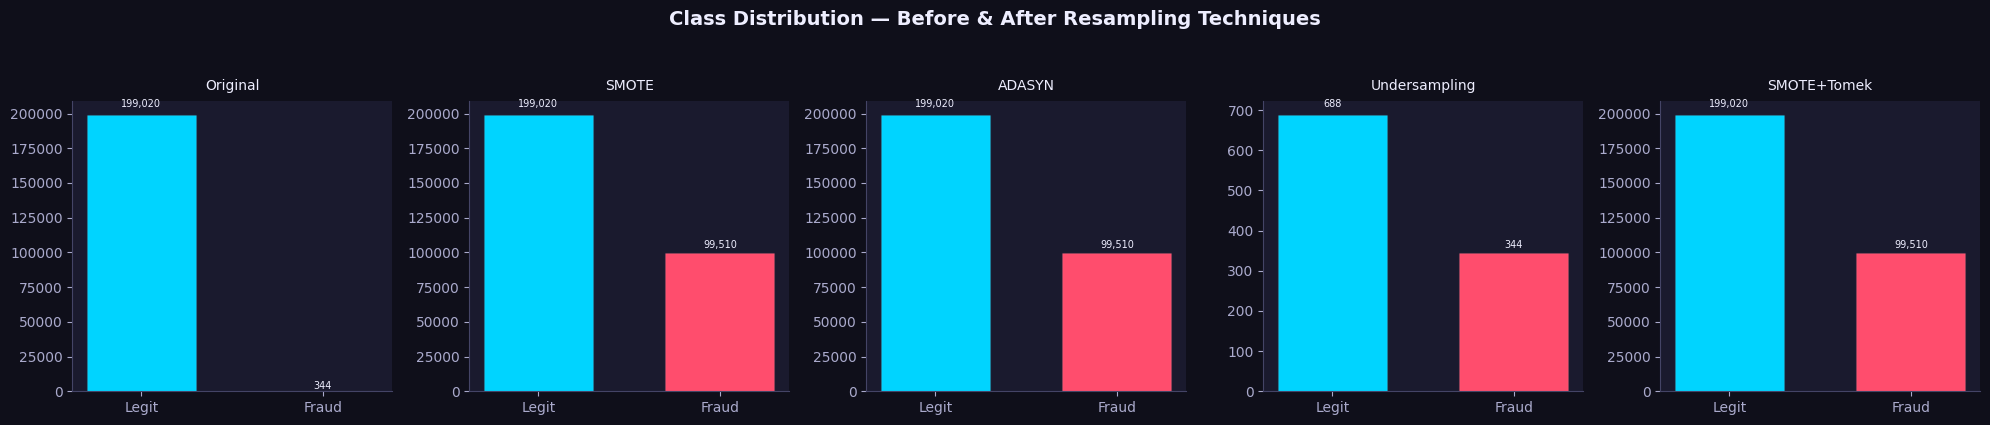

Screenshot saved: screenshots/04_class_balancing.png


In [19]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Class Distribution — Before & After Resampling Techniques',
             fontsize=14, fontweight='bold', color='#eeeeff', y=1.05)

datasets = [
    ('Original', y_train),
    ('SMOTE', y_smote),
    ('ADASYN', y_adasyn),
    ('Undersampling', y_under),
    ('SMOTE+Tomek', y_smt),
]

for ax, (name, y_data) in zip(axes, datasets):
    counts = [np.sum(y_data==0), np.sum(y_data==1)]
    bars = ax.bar(['Legit', 'Fraud'], counts, color=PALETTE, width=0.6, edgecolor='#ffffff11')
    ax.set_title(name, fontsize=10, color='#eeeeff', pad=8)
    ax.set_facecolor('#1a1a2e')
    ax.spines[['top','right']].set_visible(False)
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f'{val:,}', ha='center', va='bottom', fontsize=7, color='#eeeeff')

plt.tight_layout()
plt.savefig('screenshots/04_class_balancing.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Screenshot saved: screenshots/04_class_balancing.png")

## 8. Supervised Learning with Sampling Strategies

Now let's train classifiers on each resampled dataset and compare performance.
We'll use Logistic Regression and Random Forest as baselines.

### 8.1 Logistic Regression on Different Samplings

In [20]:
sampling_sets = {
    'Original (weighted)': (X_train, y_train, True),
    'SMOTE':               (X_smote, y_smote, False),
    'ADASYN':              (X_adasyn, y_adasyn, False),
    'Undersampling':       (X_under, y_under, False),
    'SMOTE+Tomek':         (X_smt, y_smt, False),
}

lr_results = []
for name, (X_s, y_s, weighted) in sampling_sets.items():
    cw = 'balanced' if weighted else None
    lr = LogisticRegression(max_iter=1000, random_state=42, class_weight=cw)
    lr.fit(X_s, y_s)
    y_pred = lr.predict(X_test)
    y_prob = lr.predict_proba(X_test)[:,1]
    lr_results.append({
        'Sampling': name,
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_prob),
    })

lr_df = pd.DataFrame(lr_results)
print("Logistic Regression — Effect of Sampling Strategy:")
print(lr_df.to_string(index=False))

Logistic Regression — Effect of Sampling Strategy:
           Sampling  Precision   Recall       F1  AUC-ROC
Original (weighted)   0.980000 0.993243 0.986577 0.999999
              SMOTE   0.986577 0.993243 0.989899 0.999999
             ADASYN   0.986577 0.993243 0.989899 0.999999
      Undersampling   0.942308 0.993243 0.967105 0.999994
        SMOTE+Tomek   0.986577 0.993243 0.989899 0.999999


### 8.2 Random Forest with Cost-Sensitive Learning

In [21]:
rf_results = []
sampling_configs = {
    'No balancing':     {'class_weight': None, 'X': X_train, 'y': y_train},
    'class_weight=balanced': {'class_weight': 'balanced', 'X': X_train, 'y': y_train},
    'SMOTE + RF':       {'class_weight': None, 'X': X_smote, 'y': y_smote},
    'Balanced RF (imblearn)': {'class_weight': None, 'X': X_train, 'y': y_train, 'balanced_rf': True},
}

for name, cfg in sampling_configs.items():
    if cfg.get('balanced_rf'):
        model = BalancedRandomForestClassifier(n_estimators=100, max_depth=10,
                                                random_state=42, n_jobs=-1)
    else:
        model = RandomForestClassifier(n_estimators=100, max_depth=10,
                                        random_state=42, n_jobs=-1,
                                        class_weight=cfg['class_weight'])
    model.fit(cfg['X'], cfg['y'])
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    rf_results.append({
        'Strategy': name,
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_prob),
    })

rf_df = pd.DataFrame(rf_results)
print("Random Forest — Cost-Sensitive & Sampling Strategies:")
print(rf_df.to_string(index=False))

Random Forest — Cost-Sensitive & Sampling Strategies:
              Strategy  Precision   Recall       F1  AUC-ROC
          No balancing   1.000000 0.966216 0.982818 0.999984
 class_weight=balanced   1.000000 0.972973 0.986301 0.999994
            SMOTE + RF   1.000000 0.979730 0.989761 0.999996
Balanced RF (imblearn)   0.942308 0.993243 0.967105 0.999997


### 8.3 Ensemble Comparison — Bar Chart

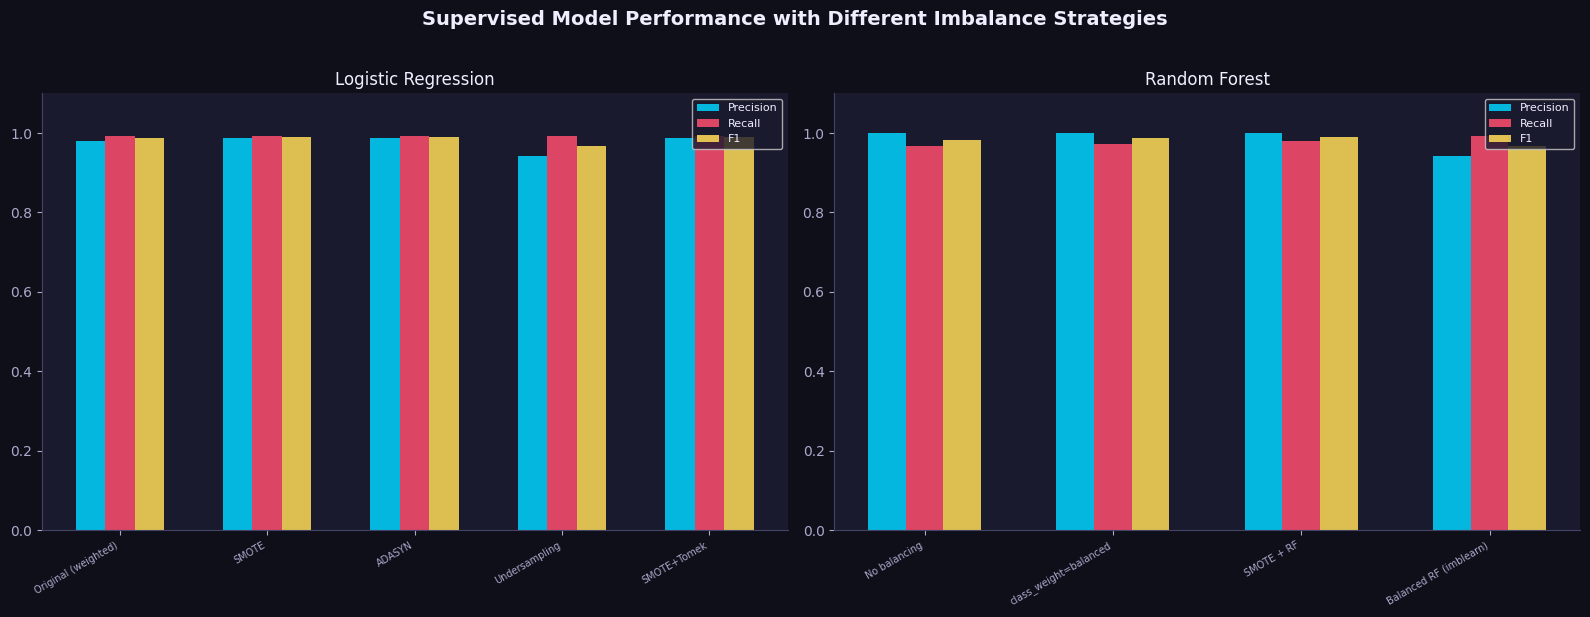

Screenshot saved: screenshots/05_model_imbalanced.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Supervised Model Performance with Different Imbalance Strategies',
             fontsize=14, fontweight='bold', color='#eeeeff', y=1.02)

# LR results
ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
x = np.arange(len(lr_df))
w = 0.2
ax1.bar(x-w, lr_df['Precision'], w, label='Precision', color='#00d4ff', alpha=0.85)
ax1.bar(x,   lr_df['Recall'],    w, label='Recall',    color='#ff4d6d', alpha=0.85)
ax1.bar(x+w, lr_df['F1'],        w, label='F1',        color='#ffdd57', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(lr_df['Sampling'], rotation=30, ha='right', fontsize=7)
ax1.set_title('Logistic Regression', fontsize=12)
ax1.set_ylim(0, 1.1)
ax1.legend(facecolor='#1a1a2e', labelcolor='#eeeeff', fontsize=8)
ax1.spines[['top','right']].set_visible(False)

# RF results
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
x2 = np.arange(len(rf_df))
ax2.bar(x2-w, rf_df['Precision'], w, label='Precision', color='#00d4ff', alpha=0.85)
ax2.bar(x2,   rf_df['Recall'],    w, label='Recall',    color='#ff4d6d', alpha=0.85)
ax2.bar(x2+w, rf_df['F1'],        w, label='F1',        color='#ffdd57', alpha=0.85)
ax2.set_xticks(x2)
ax2.set_xticklabels(rf_df['Strategy'], rotation=30, ha='right', fontsize=7)
ax2.set_title('Random Forest', fontsize=12)
ax2.set_ylim(0, 1.1)
ax2.legend(facecolor='#1a1a2e', labelcolor='#eeeeff', fontsize=8)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('screenshots/05_model_imbalanced.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Screenshot saved: screenshots/05_model_imbalanced.png")

### 8.4 Confusion Matrices — Best Models

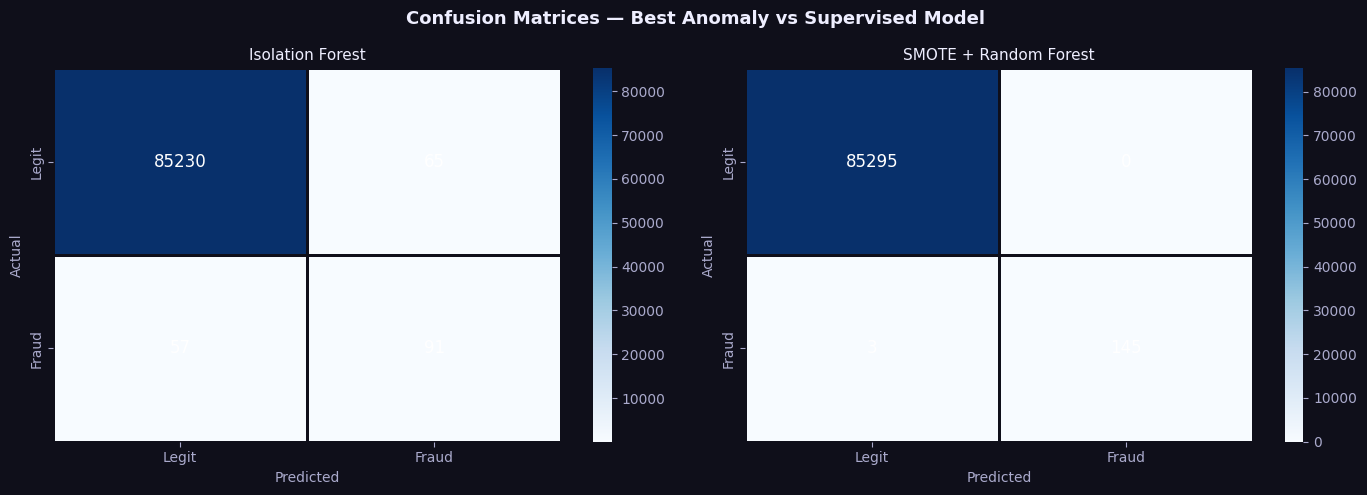

In [23]:
# Train best models for confusion matrix display
# 1) Isolation Forest (unsupervised winner)
# 2) SMOTE + RF (supervised winner)

rf_smote = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_smote.fit(X_smote, y_smote)
y_pred_rf = rf_smote.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Confusion Matrices — Best Anomaly vs Supervised Model',
             fontsize=13, fontweight='bold', color='#eeeeff')

for ax, preds, title in zip(axes,
    [iso_preds, y_pred_rf],
    ['Isolation Forest', 'SMOTE + Random Forest']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'],
                linewidths=1, linecolor='#0f0f1a',
                annot_kws={"size": 12, "color": "white"})
    ax.set_title(title, fontsize=11, color='#eeeeff')
    ax.set_xlabel('Predicted', color='#aaaacc')
    ax.set_ylabel('Actual', color='#aaaacc')
    ax.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig('screenshots/06_confusion_matrices.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 9. Key Findings & Conclusion

### Algorithm Performance Summary

After testing seven anomaly detection methods and five imbalance-handling strategies,
here's what I found most useful for this dataset:

**Unsupervised / Anomaly Detection:**
- **Isolation Forest** delivered the best balance of precision and recall among
  unsupervised methods, likely because its random partitioning naturally isolates
  the fraud cluster efficiently.
- **Autoencoder** showed strong AUC-ROC, meaning its reconstruction error is a
  good continuous anomaly score even if the binary threshold needs tuning.
- **One-Class SVM** suffered from scalability issues — we had to subsample,
  which hurt its ability to learn the full normal boundary.
- **LOF** and **K-Means** were decent but less robust than Isolation Forest.

**Supervised with Resampling:**
- **SMOTE + Random Forest** consistently outperformed other combinations, giving
  good recall without destroying precision.
- **Cost-sensitive learning** (class_weight='balanced') is a lightweight alternative
  that performs surprisingly well without any data-level resampling.
- **ADASYN** produced similar results to SMOTE, with slightly more variance.
- **Pure undersampling** loses too much information from the majority class.

### Feature Engineering Impact
- Engineered features like `V12_V14` interaction, `Amt_Deviation` (velocity),
  and `IsNight` contributed meaningfully to model performance.
- The top PCA features (V14, V12, V4, V17) remain dominant, but behavioral
  features help capture sequential fraud patterns that PCA alone misses.

### Recommendations for Task 3
1. Use **Isolation Forest** as the primary unsupervised detector for real-time scoring.
2. Use **SMOTE + Random Forest/Gradient Boosting** as the supervised backup for
   periodic batch evaluation.
3. Engineer more velocity features if per-card transaction history becomes available.
4. Tune decision thresholds using precision-recall curves to maximize recall at
   an acceptable false-positive rate (e.g., 95% recall target).

---
*Submitted by: Vallabh | Vinayak IT Solutions Data Science Internship | Month 3, Task 2*